In [3]:
%pip install sentence-transformers seaborn matplotlib scikit-learn

  Using cached sentence_transformers-5.3.0-py3-none-any.whl (512 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached huggingface_hub-1.7.1-py3-none-any.whl (616 kB)
  Using cached transformers-5.3.0-py3-none-any.whl (10.7 MB)
  Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
  Using cached typer-0.24.1-py3-none-any.whl (56 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
  Using cached rich-14.3.3-py3-none-any.whl (310 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("All libraries loaded successfully")

c:\Users\Gokul\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries loaded successfully


In [5]:
sentences = [
    # Cricket
    "The batsman scored a brilliant century in the final match.",
    "The bowler delivered a fast yorker to dismiss the opener.",
    "The cricket team celebrated their victory after winning the tournament.",
    "The captain set an aggressive field to stop the runs.",
    
    # Cooking
    "The chef prepared a delicious pasta with fresh ingredients.",
    "Baking a cake requires precise measurements and temperature control.",
    "The soup was simmered slowly to enhance its flavor.",
    
    # Cybersecurity
    "Cybersecurity experts monitor networks to detect potential threats.",
    "Strong passwords and two factor authentication improve system security.",
    "Hackers often exploit software vulnerabilities to gain access."
]

In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

c:\Users\Gokul\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Gokul\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5150.43it/s]
BertMo

Embedding shape: (10, 384)


In [7]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 1.0000001   0.38816208  0.55549073  0.26340157  0.02457919  0.09559349
   0.03650937 -0.05544537  0.07947128  0.02379375]
 [ 0.38816208  0.99999976  0.27397376  0.34832904  0.12921287  0.02249358
   0.16439924  0.04128635 -0.02505414  0.02156156]
 [ 0.55549073  0.27397376  0.9999998   0.1534994  -0.00560993  0.05221632
   0.08344577 -0.04358372 -0.03091253  0.00257462]
 [ 0.26340157  0.34832904  0.1534994   0.99999994  0.0034429  -0.05844167
   0.01949541  0.06410144  0.02751764  0.01929434]
 [ 0.02457919  0.12921287 -0.00560993  0.0034429   1.          0.18991396
   0.36682492  0.04386288 -0.00405187  0.1264231 ]
 [ 0.09559349  0.02249358  0.05221632 -0.05844167  0.18991396  1.
   0.13107702  0.01263894 -0.02327986  0.05385353]
 [ 0.03650937  0.16439924  0.08344577  0.01949541  0.36682492  0.13107702
   1.0000001  -0.03353082  0.01374446  0.05598996]
 [-0.05544537  0.04128635 -0.04358372  0.06410144  0.04386288  0.01263894
  -0.03353082  1.0000002   0.25509     0.3930651 ]
 [ 0.079

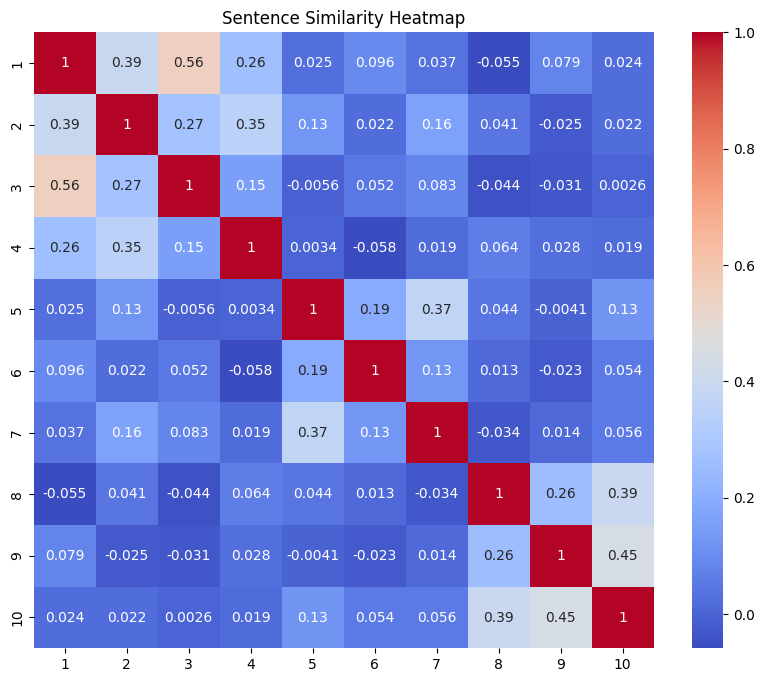

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="coolwarm",
    xticklabels=range(1,11),
    yticklabels=range(1,11)
)

plt.title("Sentence Similarity Heatmap")
plt.show()

In [9]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

In [10]:
similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(similarities)[::-1][:2]

print("Query:", query)
print()

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", similarities[i])
    print()

Query: The bowler took three wickets in one over

Sentence: The batsman scored a brilliant century in the final match.
Similarity Score: 0.5475373

Sentence: The bowler delivered a fast yorker to dismiss the opener.
Similarity Score: 0.5415581

